
# Seepage vs Δh — Linear, Offset‑Power (Main), Offset‑Power (Visitor) with Scaling, Bounds & Light Regularization

This notebook keeps **per‑event fits** and adds the exact model set and scaling you requested:

**Models**
1. **Linear (zero intercept, main driver):** \( S = K\,\Delta h \)
2. **Offset‑Power (main driver):** \( S = K\,z^b \), where \( z = \dfrac{\Delta h + c}{\mathrm{median}(\Delta h)} \)
3. **Offset‑Power (visitor driver):** \( S = K\,z_v^b \), where \( z_v = \dfrac{\text{visitor} + c_v}{\mathrm{median}(\text{visitor})} \)

with \(K>0\), \(b \in [0.5, 2]\), and **offset bounds** \(c \in [0, c_{\max}]\), \(c_v \in [0, c_{\max,v}]\).  
We compare models using centered \(R^2\), **AIC**, and \(\Delta\)AIC.

**Scaling rationale.** Defining \(z\) and \(z_v\) using **distinct medians** stabilizes parameters across events and
reduces collinearity between \(K\) and \(b\). It also makes the **offsets interpretable** relative to a typical head difference.

**Light regularization on offsets.** During fitting, we add a small L2 penalty
\(\lambda\,(c/\mathrm{median})^2\) (and \(\lambda_v\,(c_v/\mathrm{median}_{v})^2\)) to the optimization objective—**but we compute AIC from data residuals only**.
This acts like a weak prior nudging offsets toward zero, improving stability when data near \(\Delta h \approx 0\) are scarce.


In [1]:

# --- Imports & configuration ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

try:
    from ace_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 200,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# ---- Paths & knobs ----
DATA_PATH = Path("../data/processed/pooled_event_df.csv")  # Adjust as needed
VISITOR_CANDIDATES = ["delta_h_visitor", "visitor_head", "delta_h_vis"]

MIN_N_PER_EVENT = 12     # per-event minimum sample size
BOOTSTRAP_B = 500        # increase to 1000 for publication

# Median scope: use the **pooled** median by default (recommended for comparability)
MEDIAN_SCOPE = "pooled"  # options: "pooled" or "per_event"

# Offset bounds: choose strategy and hyperparams
OFFSET_BOUND_MODE = "quantile"  # options: "quantile" or "k_median"
OFFSET_BOUND_Q = 0.95           # if "quantile", c_max = quantile(x, Q)
OFFSET_BOUND_K = 2.0            # if "k_median", c_max = K * median(x)

# Light L2 regularization on offsets (dimensionless via dividing by the relevant median)
# The penalty is:  lam * (c/median)^2 * (n * var(y))  added to the SSE when fitting.
# Using n*var(y) keeps the penalty on the same scale as the data SSE.
LAMBDA_OFFSET_MAIN = 0.1
LAMBDA_OFFSET_VIS  = 0.1



## 1) Load data & apply a single filter; compute distinct medians

**Required columns:** `delta_h`, `seepage`  
**Optional:** `event` for per‑event fits; a visitor driver (auto‑detected: `delta_h_visitor`, `visitor_head`, or `delta_h_vis`).

QC here is **single and fixed** for the analysis: keep nonnegative values.


In [2]:

# --- Load ---
df = pd.read_csv(DATA_PATH)

# Ensure presence and numeric types
for col in ["delta_h", "seepage"]:
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' is missing from {DATA_PATH}")
df["delta_h"] = pd.to_numeric(df["delta_h"], errors="coerce")
df["seepage"] = pd.to_numeric(df["seepage"], errors="coerce")

# Fixed QC
df = df.dropna(subset=["delta_h","seepage"]).copy()
df = df.query("delta_h >= 0 and seepage >= 0").copy()

has_event = "event" in df.columns

# Detect visitor driver
visitor_candidates = [c for c in VISITOR_CANDIDATES if c in df.columns]
visitor_col = visitor_candidates[0] if visitor_candidates else None
if visitor_col:
    df[visitor_col] = pd.to_numeric(df[visitor_col], errors="coerce")
    df = df.dropna(subset=[visitor_col]).copy()
    df = df.query(f"{visitor_col} >= 0").copy()

# Arrays
x_main = df["delta_h"].to_numpy()
y = df["seepage"].to_numpy()
x_vis = df[visitor_col].to_numpy() if visitor_col else None

# Robust medians (pooled by default)
def robust_median(x):
    m = np.nanmedian(x)
    if not np.isfinite(m) or m <= 0:
        pos = x[np.isfinite(x) & (x > 0)]
        if pos.size > 0:
            m = np.nanmedian(pos)
        else:
            m = np.nanpercentile(x, 75) if np.isfinite(np.nanpercentile(x, 75)) else 1.0
    if m <= 0 or not np.isfinite(m):
        m = 1.0
    return float(m)

med_main_pooled = robust_median(x_main)
med_vis_pooled  = robust_median(x_vis) if x_vis is not None else np.nan

print(f"N = {len(df)} rows" + (f", events = {df['event'].nunique()}" if has_event else ""))
if visitor_col:
    print(f"Visitor driver detected: '{visitor_col}'")
print(f"Pooled medians -> main: {med_main_pooled:.6g}" + (f", visitor: {med_vis_pooled:.6g}" if visitor_col else ""))


N = 493 rows, events = 56
Pooled medians -> main: 1.68013



## 2) Models, bounds, and light offset regularization

We fit three models:

- **Linear (main):** \(S=K\,\Delta h\)  
- **Offset‑Power (main):** \(S=K\,z^b\), \(z=\frac{\Delta h + c}{m}\), \(m=\mathrm{median}(\Delta h)\) (or per‑event median if configured)  
- **Offset‑Power (visitor):** \(S=K\,z_v^b\), \(z_v=\frac{\text{visitor} + c_v}{m_v}\), \(m_v=\mathrm{median}(\text{visitor})\)

**Bounds.** We constrain \(K>0\), \(b\in[0.5,2]\), and offsets \(c\in[0,c_{\max}]\), \(c_v\in[0,c_{\max,v}]\), with \(c_{\max}\) chosen either by a high quantile or by a multiple of the median.

**Light regularization.** During optimization only (not in AIC), we add
\(\lambda\,(c/m)^2\,\underbrace{n\,\mathrm{Var}(y)}_{\text{SSE scale}}\)
which is a weak, dimensionless penalty (like a Gaussian prior) that nudges \(c\) toward 0 and improves stability.


In [3]:

# --- Helper utilities ---
def compute_median(x, scope="pooled", pooled_value=None, x_event=None):
    if scope == "pooled":
        return float(pooled_value)
    else:
        return float(np.nanmedian(x_event)) if x_event is not None else float(pooled_value)

def compute_cmax(x, med, mode="quantile", q=0.95, k=2.0):
    if mode == "quantile":
        cmax = np.nanquantile(x, q)
    else:
        cmax = k * med
    return float(max(1e-12, cmax))

def penalty_scale(y):
    return float(max(1e-12, len(y) * np.nanvar(y)))

# --- Models ---
def model_linear(params, x):
    K, = params
    return K * x

def model_offset_power_scaled(params, x, med):
    # params = (K, b, c);   z = (x + c)/med
    K, b, c = params
    z = (np.clip(x, 0, None) + c) / med
    return K * np.power(z, b)

# --- Objectives (SSE + light L2 on c) ---
def sse_linear(params, x, y):
    yhat = model_linear(params, x)
    if not np.all(np.isfinite(yhat)):
        return np.inf
    return np.sum((y - yhat) ** 2)

def sse_offset_power_scaled(params, x, y, med, lam):
    K, b, c = params
    if K <= 0 or not np.isfinite(b) or c < 0:
        return np.inf
    yhat = model_offset_power_scaled(params, x, med)
    if not np.all(np.isfinite(yhat)):
        return np.inf
    sse = np.sum((y - yhat) ** 2)
    pen = lam * (c / med) ** 2 * penalty_scale(y)
    return sse + pen

# --- Metrics ---
def r2_centered(y, yhat):
    resid = y - yhat
    sse = np.sum(resid**2)
    tss = np.sum((y - y.mean())**2)
    return 1.0 - sse / tss if tss > 0 else np.nan

def aic_gaussian_from_yhat(y, yhat, k_params):
    n = len(y)
    sse = np.sum((y - yhat)**2)  # DATA SSE only (regularization not included)
    sigma2 = sse / n
    return n * np.log(sigma2) + 2 * k_params

# --- Fitters ---
def fit_linear(x, y):
    den = np.sum(x * x)
    K = np.sum(x * y) / den if den > 0 else np.nan
    yhat = model_linear((K,), x)
    return {"params": (K,), "yhat": yhat, "R2": r2_centered(y, yhat), "AIC": aic_gaussian_from_yhat(y, yhat, 1)}

def fit_offset_power_scaled(x, y, med, lam, cmax, K0=None, b0=1.0, c0=None):
    # Initialize using c=0 linearized guess
    if K0 is None:
        z0 = (x + 0.0) / med
        den = np.sum(z0 * z0)
        K0 = np.sum(z0 * y) / den if den > 0 else (y.mean() / (z0.mean() + 1e-12))
    if c0 is None:
        c0 = 0.1 * cmax

    bounds = [(1e-12, None), (0.5, 2.0), (0.0, cmax)]
    res = minimize(lambda p: sse_offset_power_scaled(p, x, y, med, lam),
                   x0=np.array([max(K0,1e-12), b0, min(max(c0,0.0), cmax)], dtype=float),
                   method="L-BFGS-B", bounds=bounds)

    K, b, c = res.x
    yhat = model_offset_power_scaled((K,b,c), x, med)
    return {"params": (K, b, c), "yhat": yhat, "R2": r2_centered(y, yhat), "AIC": aic_gaussian_from_yhat(y, yhat, 3)}



## 3) Pooled fits

We fit **Linear** (main), **Offset‑Power (main)** with \(z=(\Delta h+c)/m\), and **Offset‑Power (visitor)** with \(z_v=(\text{visitor}+c_v)/m_v\).
Bounds for \(c\) are chosen by the configured strategy; AIC is computed from **data residuals only**.


In [4]:

# Medians for pooled scope
med_main = med_main_pooled
med_vis  = med_vis_pooled if np.isfinite(med_vis_pooled) else np.nan

# Offset bounds (pooled)
cmax_main = compute_cmax(x_main, med_main, mode=OFFSET_BOUND_MODE, q=OFFSET_BOUND_Q, k=OFFSET_BOUND_K)
cmax_vis  = compute_cmax(x_vis,  med_vis,  mode=OFFSET_BOUND_MODE, q=OFFSET_BOUND_Q, k=OFFSET_BOUND_K) if x_vis is not None else np.nan

# Fit pooled models
res_lin_main = fit_linear(x_main, y)

res_off_main = fit_offset_power_scaled(x_main, y, med_main, LAMBDA_OFFSET_MAIN, cmax_main, K0=res_lin_main["params"][0], b0=1.0, c0=None)

res_off_vis = None
if x_vis is not None:
    res_off_vis = fit_offset_power_scaled(x_vis, y, med_vis, LAMBDA_OFFSET_VIS, cmax_vis, K0=None, b0=1.0, c0=None)

# Summarize
rows = [
    {"Model": "Linear (main)", "K": res_lin_main["params"][0], "b": np.nan, "c": np.nan,
     "R2": res_lin_main["R2"], "AIC": res_lin_main["AIC"]},
    {"Model": "Offset‑Power (main)", "K": res_off_main["params"][0], "b": res_off_main["params"][1], "c": res_off_main["params"][2],
     "R2": res_off_main["R2"], "AIC": res_off_main["AIC"]},
]
if res_off_vis is not None:
    rows.append({"Model": "Offset‑Power (visitor)", "K": res_off_vis["params"][0], "b": res_off_vis["params"][1], "c": res_off_vis["params"][2],
                 "R2": res_off_vis["R2"], "AIC": res_off_vis["AIC"]})

pooled_tbl = pd.DataFrame(rows)
pooled_tbl["ΔAIC"] = pooled_tbl["AIC"] - pooled_tbl["AIC"].min()

if display_dataframe_to_user:
    display_dataframe_to_user("Pooled fit summary (scaled offset models)", pooled_tbl)
else:
    display(pooled_tbl)

best_row = pooled_tbl.loc[pooled_tbl["AIC"].idxmin()]
print(f"Preferred pooled model by AIC: {best_row['Model']}  (ΔAIC = {best_row['ΔAIC']:.1f})")
print(f"Medians used -> main: {med_main:.6g}" + (f", visitor: {med_vis:.6g}" if x_vis is not None else ""))
print(f"Offset bounds -> c_max(main)={cmax_main:.6g}" + (f", c_max(visitor)={cmax_vis:.6g}" if x_vis is not None else ""))


,Model,K,b,c,R2,AIC,ΔAIC
0,Linear (main),1.083792,NaN,NaN,0.369719,-353.459706,2.896042
1,Offset‑Power (main),1.620237,1.28333,0.133576,0.378474,-356.355748,0.000000


Preferred pooled model by AIC: Offset‑Power (main)  (ΔAIC = 0.0)
Medians used -> main: 1.68013
Offset bounds -> c_max(main)=2.33481



## 4) Bootstrap 95% CIs (pooled)

Residual bootstrap with the same scaling, bounds, and λ; AIC is not used here—just parameter CIs.


In [5]:

def bootstrap_linear(x, y, B=BOOTSTRAP_B, seed=123):
    rng = np.random.default_rng(seed)
    # base residuals from linear fit
    base = fit_linear(x, y)
    resid = y - base["yhat"]
    K_s = []
    for _ in range(B):
        eps = rng.choice(resid, size=len(resid), replace=True)
        y_star = base["yhat"] + eps
        K_s.append(fit_linear(x, y_star)["params"][0])
    return np.nanpercentile(K_s, [2.5, 50, 97.5])

def bootstrap_offset_scaled(x, y, med, lam, cmax, B=BOOTSTRAP_B, seed=123):
    rng = np.random.default_rng(seed)
    base = fit_offset_power_scaled(x, y, med, lam, cmax)
    resid = y - base["yhat"]
    K_s, b_s, c_s = [], [], []
    for _ in range(B):
        eps = rng.choice(resid, size=len(resid), replace=True)
        y_star = base["yhat"] + eps
        res = fit_offset_power_scaled(x, y_star, med, lam, cmax)
        K, b, c = res["params"]
        K_s.append(K); b_s.append(b); c_s.append(c)
    K_ci = np.nanpercentile(K_s, [2.5, 50, 97.5])
    b_ci = np.nanpercentile(b_s, [2.5, 50, 97.5])
    c_ci = np.nanpercentile(c_s, [2.5, 50, 97.5])
    return K_ci, b_ci, c_ci

K_lin_ci = bootstrap_linear(x_main, y)

K_off_main_ci = bootstrap_offset_scaled(x_main, y, med_main, LAMBDA_OFFSET_MAIN, cmax_main)

K_off_vis_ci = None
if x_vis is not None:
    K_off_vis_ci = bootstrap_offset_scaled(x_vis, y, med_vis, LAMBDA_OFFSET_VIS, cmax_vis)

def ci_row(name, est, cis):
    row = {"Model": name}
    for i, (v, ci) in enumerate(zip(est, cis)):
        lo, med, hi = ci
        row[f"param{i+1}_est"] = v
        row[f"param{i+1}_lo"]  = lo
        row[f"param{i+1}_hi"]  = hi
    return row

rows = [
    ci_row("Linear (K)", (res_lin_main["params"][0],), (K_lin_ci,)),
    ci_row("Offset‑Power (main) (K,b,c)", res_off_main["params"], K_off_main_ci),
]
if res_off_vis is not None and K_off_vis_ci is not None:
    rows.append(ci_row("Offset‑Power (visitor) (K,b,c)", res_off_vis["params"], K_off_vis_ci))

ci_tbl = pd.DataFrame(rows)
if display_dataframe_to_user:
    display_dataframe_to_user("Pooled parameter bootstrap 95% CIs", ci_tbl)
else:
    display(ci_tbl)


,Model,param1_est,param1_lo,param1_hi,param2_est,param2_lo,param2_hi,param3_est,param3_lo,param3_hi
0,Linear (K),1.083792,1.042453,1.110851,NaN,NaN,NaN,NaN,NaN,NaN
1,"Offset‑Power (main) (K,b,c)",1.620237,1.638372,1.853370,1.28333,1.031621,1.35764,0.133576,0.0,0.117713



## 5) Figures (pooled)

Separate views for the two drivers:

- \(S\) vs \(\Delta h\) with **Linear** and **Offset‑Power (main)** overlays.  
- If available, \(S\) vs **visitor** with **Offset‑Power (visitor)** overlay.  
- Residuals vs fitted for the **AIC‑best** pooled model.


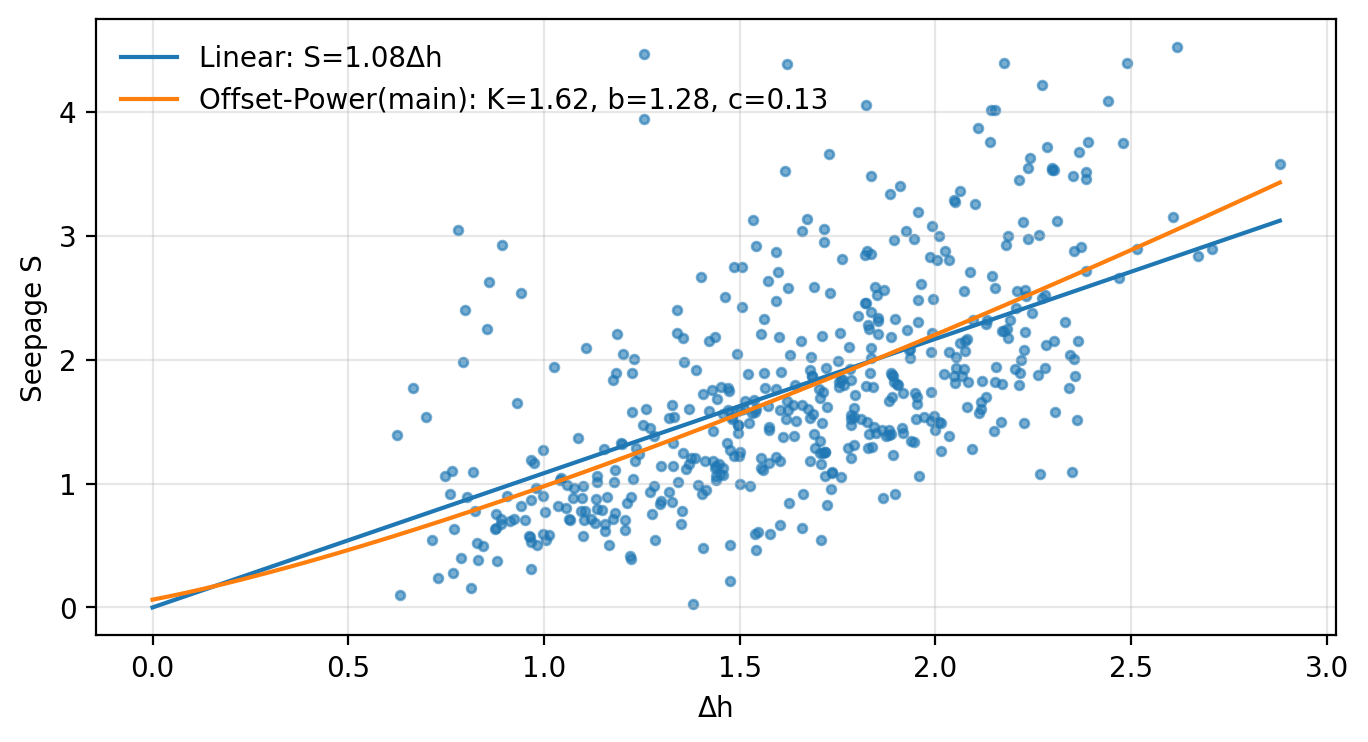

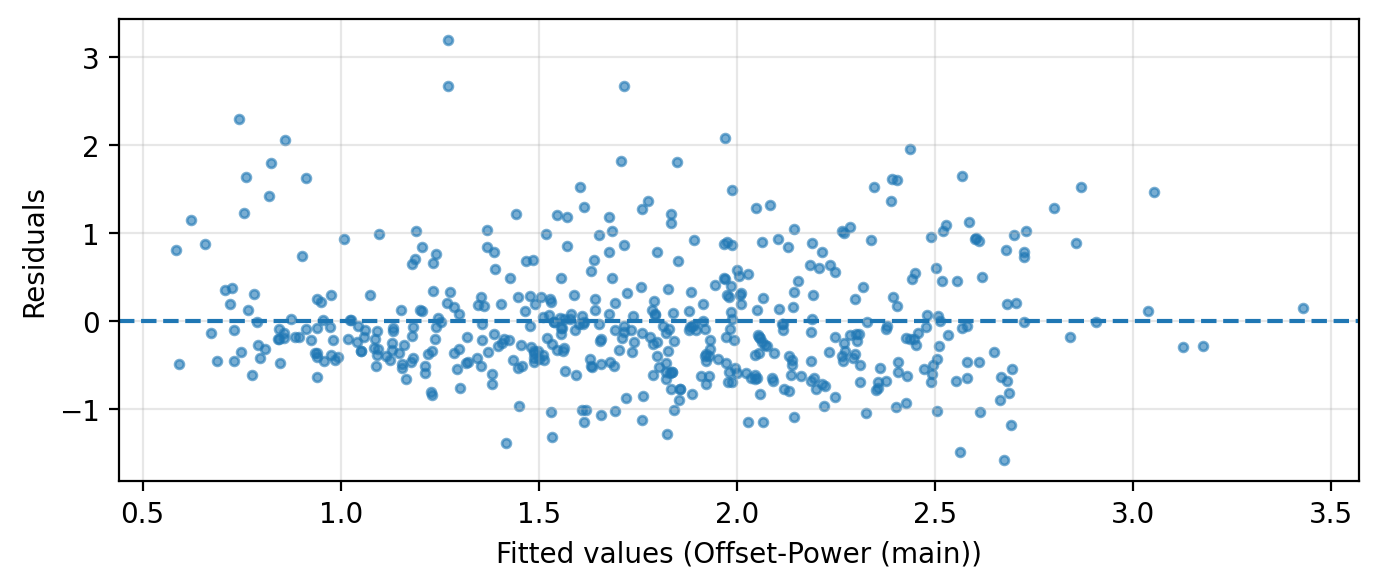

In [6]:

# 5a) S vs Δh
fig = plt.figure(figsize=(8,4))
ax = plt.gca()
ax.scatter(x_main, y, s=10, alpha=0.6)
xs = np.linspace(0, np.nanmax(x_main), 200)
# Linear
K_lin = res_lin_main["params"][0]
ax.plot(xs, model_linear((K_lin,), xs), label=f"Linear: S={K_lin:.3g}Δh")
# Offset‑Power (main)
K_m, b_m, c_m = res_off_main["params"]
ax.plot(xs, model_offset_power_scaled((K_m, b_m, c_m), xs, med_main), label=f"Offset‑Power(main): K={K_m:.3g}, b={b_m:.2f}, c={c_m:.2g}")
ax.set_xlabel("Δh")
ax.set_ylabel("Seepage S")
ax.legend(frameon=False)
plt.show()

# 5b) S vs visitor (if available)
if x_vis is not None and res_off_vis is not None:
    fig = plt.figure(figsize=(8,4))
    ax = plt.gca()
    ax.scatter(x_vis, y, s=10, alpha=0.6)
    xs_v = np.linspace(0, np.nanmax(x_vis), 200)
    K_v, b_v, c_v = res_off_vis["params"]
    ax.plot(xs_v, model_offset_power_scaled((K_v, b_v, c_v), xs_v, med_vis), label=f"Offset‑Power(visitor): K={K_v:.3g}, b={b_v:.2f}, c={c_v:.2g}")
    ax.set_xlabel(visitor_col)
    ax.set_ylabel("Seepage S")
    ax.legend(frameon=False)
    plt.show()

# 5c) Residuals vs fitted (AIC‑best overall pooled model)
yhat_best = None
best_name = pooled_tbl.loc[pooled_tbl["AIC"].idxmin(), "Model"]
if best_name == "Linear (main)":
    yhat_best = res_lin_main["yhat"]
elif best_name == "Offset‑Power (main)":
    yhat_best = res_off_main["yhat"]
else:
    yhat_best = res_off_vis["yhat"] if res_off_vis is not None else res_off_main["yhat"]

fig = plt.figure(figsize=(8,3))
ax = plt.gca()
ax.scatter(yhat_best, y - yhat_best, s=10, alpha=0.6)
ax.axhline(0, linestyle="--")
ax.set_xlabel(f"Fitted values ({best_name})")
ax.set_ylabel("Residuals")
plt.show()



## 6) Per‑event fits

For each event with at least `MIN_N_PER_EVENT` points, we fit:
- **Linear (main)**
- **Offset‑Power (main)** using \(z=(\Delta h+c)/m\)
- **Offset‑Power (visitor)** using \(z_v=(\text{visitor}+c_v)/m_v\) (if visitor column exists)

**Medians.** By default we use **pooled** medians \(m, m_v\) for all events (toggle `MEDIAN_SCOPE` to use per‑event medians).  
**Bounds.** \(c_{\max}\) and \(c_{\max,v}\) are computed per event via the same strategy.


,event,n,best_model,K_linear,K_off_main,b_off_main,c_off_main,R2_linear,R2_off_main,AIC_linear,AIC_off_main,ΔAIC_linear,ΔAIC_off_main
0,0,28,Linear (main),0.787971,1.343733,0.801638,0.000000,0.386280,0.403613,-54.168863,-50.971010,0.000000,3.197854
1,1,25,Linear (main),0.946948,1.570274,1.421262,0.000000,0.640534,0.690871,-72.530524,-72.302064,0.000000,0.228460
2,2,28,Linear (main),1.018414,1.501128,1.359602,0.086306,0.724660,0.751901,-54.778731,-53.695740,0.000000,1.082991
5,5,17,Linear (main),1.200827,2.025117,1.404239,0.000000,0.412687,0.449822,-11.594269,-8.704645,0.000000,2.889624
6,6,18,Linear (main),0.895087,1.475959,1.263249,0.000000,0.790195,0.817737,-42.691790,-41.224937,0.000000,1.466853
7,7,17,Linear (main),0.544264,0.942683,1.068726,0.000000,0.276830,0.277865,-61.837033,-57.861366,0.000000,3.975668
9,9,22,Linear (main),1.657023,2.805651,0.940482,0.000000,0.831856,0.834484,-54.271121,-50.617643,0.000000,3.653478
10,10,21,Linear (main),1.411487,2.221859,1.209627,0.042624,0.670172,0.681051,-25.394176,-22.098534,0.000000,3.295643
11,13,17,Linear (main),0.883530,1.524855,0.661172,0.000000,0.428832,0.540732,-41.980285,-41.687137,0.000000,0.293147
13,15,12,Linear (main),0.718862,1.195106,0.868659,0.000000,0.250496,0.255344,-29.599194,-25.677062,0.000000,3.922131


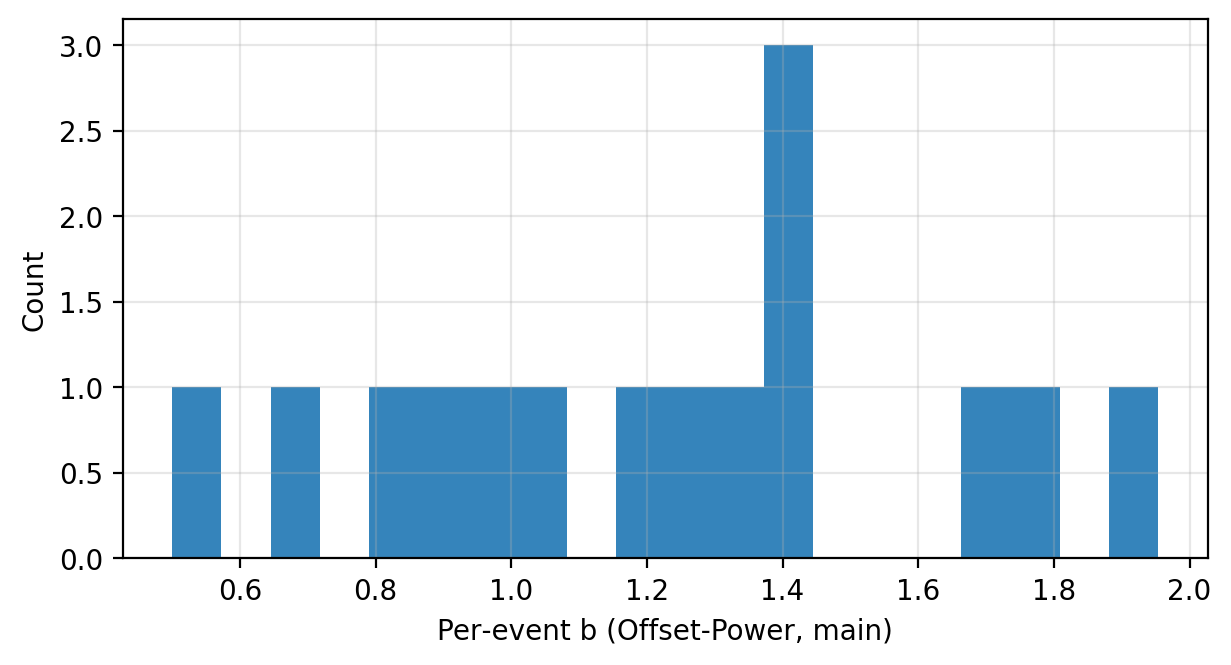

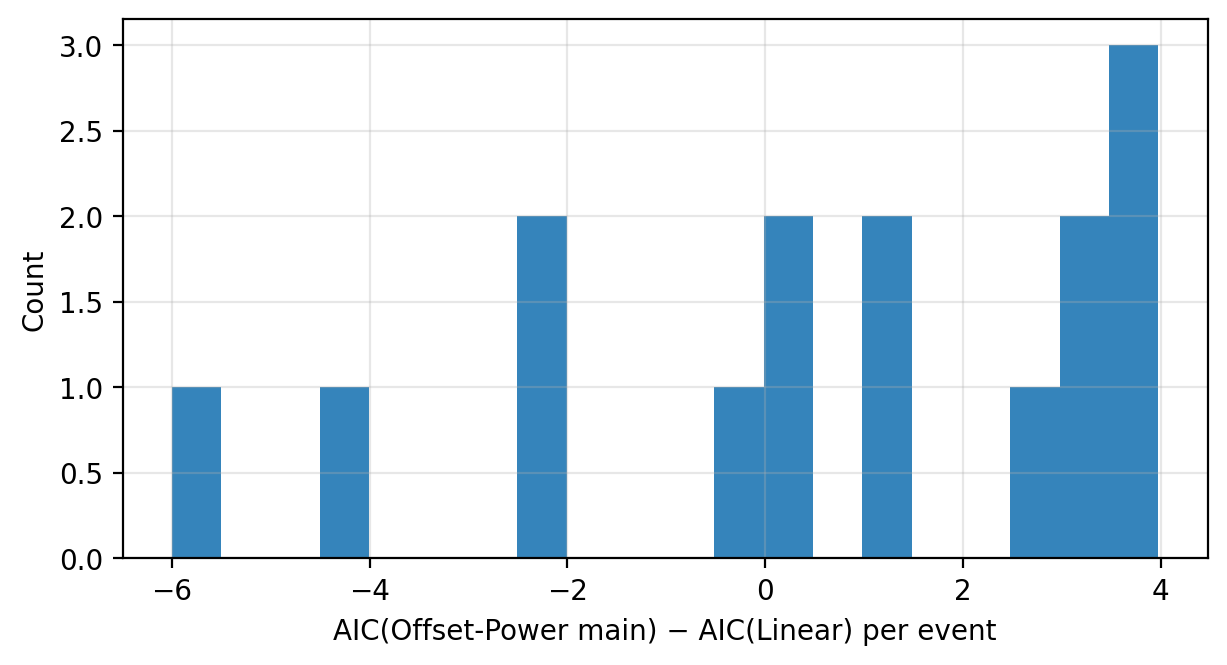

In [7]:

per_event_tbl = None
if has_event:
    rows = []
    for eid, g in df.groupby("event"):
        if len(g) < MIN_N_PER_EVENT:
            continue

        x_e = g["delta_h"].to_numpy()
        y_e = g["seepage"].to_numpy()
        med_e_main = med_main_pooled if MEDIAN_SCOPE=="pooled" else np.nanmedian(x_e)
        med_e_main = med_e_main if med_e_main>0 else med_main_pooled
        cmax_e_main = compute_cmax(x_e, med_e_main, mode=OFFSET_BOUND_MODE, q=OFFSET_BOUND_Q, k=OFFSET_BOUND_K)

        # Linear + Offset‑Power (main)
        rL = fit_linear(x_e, y_e)
        rM = fit_offset_power_scaled(x_e, y_e, med_e_main, LAMBDA_OFFSET_MAIN, cmax_e_main)

        # Offset‑Power (visitor), if available
        rV = None
        if visitor_col:
            xv_e = g[visitor_col].to_numpy()
            med_e_vis = med_vis_pooled if MEDIAN_SCOPE=="pooled" else np.nanmedian(xv_e)
            med_e_vis = med_e_vis if med_e_vis>0 else (med_vis_pooled if np.isfinite(med_vis_pooled) else 1.0)
            cmax_e_vis = compute_cmax(xv_e, med_e_vis, mode=OFFSET_BOUND_MODE, q=OFFSET_BOUND_Q, k=OFFSET_BOUND_K)
            rV = fit_offset_power_scaled(xv_e, y_e, med_e_vis, LAMBDA_OFFSET_VIS, cmax_e_vis)

        # AIC comparison for the models present
        aics = {"Linear (main)": rL["AIC"], "Offset‑Power (main)": rM["AIC"]}
        if rV is not None:
            aics["Offset‑Power (visitor)"] = rV["AIC"]
        dAIC = {k: v - min(aics.values()) for k,v in aics.items()}
        best = min(aics, key=aics.get)

        # Collect params
        K_L, = rL["params"]
        K_M, b_M, c_M = rM["params"]
        row = {
            "event": eid, "n": len(g), "best_model": best,
            "K_linear": K_L,
            "K_off_main": K_M, "b_off_main": b_M, "c_off_main": c_M,
            "R2_linear": rL["R2"], "R2_off_main": rM["R2"],
            "AIC_linear": rL["AIC"], "AIC_off_main": rM["AIC"],
            "ΔAIC_linear": dAIC["Linear (main)"], "ΔAIC_off_main": dAIC["Offset‑Power (main)"],
        }

        if rV is not None:
            K_V, b_V, c_V = rV["params"]
            row.update({
                "K_off_vis": K_V, "b_off_vis": b_V, "c_off_vis": c_V,
                "R2_off_vis": rV["R2"], "AIC_off_vis": rV["AIC"],
                "ΔAIC_off_vis": dAIC["Offset‑Power (visitor)"],
            })
        rows.append(row)

    per_event_tbl = pd.DataFrame(rows).sort_values(["best_model","event"])
    if display_dataframe_to_user:
        display_dataframe_to_user("Per‑event fit summary", per_event_tbl)
    else:
        display(per_event_tbl.head(20))

    # Quick distributions
    if not per_event_tbl.empty:
        # b (Offset‑Power main)
        fig = plt.figure(figsize=(7,3.5))
        ax = plt.gca()
        ax.hist(per_event_tbl["b_off_main"].dropna().to_numpy(), bins=20, alpha=0.9)
        ax.set_xlabel("Per‑event b (Offset‑Power, main)")
        ax.set_ylabel("Count")
        plt.show()

        # AIC(Offset‑Power main) - AIC(Linear)
        fig = plt.figure(figsize=(7,3.5))
        ax = plt.gca()
        diff = per_event_tbl["AIC_off_main"].to_numpy() - per_event_tbl["AIC_linear"].to_numpy()
        ax.hist(diff, bins=20, alpha=0.9)
        ax.set_xlabel("AIC(Offset‑Power main) − AIC(Linear) per event")
        ax.set_ylabel("Count")
        plt.show()

        # If visitor exists, ΔAIC visitor vs main where available
        if visitor_col and "AIC_off_vis" in per_event_tbl.columns:
            fig = plt.figure(figsize=(7,3.5))
            ax = plt.gca()
            mask = per_event_tbl["AIC_off_vis"].notna()
            ax.hist((per_event_tbl.loc[mask,"AIC_off_vis"] - per_event_tbl.loc[mask,"AIC_off_main"]).to_numpy(), bins=20, alpha=0.9)
            ax.set_xlabel("AIC(Offset‑Power visitor) − AIC(Offset‑Power main) per event")
            ax.set_ylabel("Count")
            plt.show()
else:
    print("Per‑event fits skipped (no 'event' column).")



## 7) Plain‑English conclusion (auto‑filled)


In [8]:

lines = []
lines.append(f"Pooled medians used: main={med_main:.3g}" + (f", visitor={med_vis:.3g}" if np.isfinite(med_vis) else ""))
lines.append(f"Pooled offset bounds: c_max(main)={cmax_main:.3g}" + (f", c_max(visitor)={cmax_vis:.3g}" if np.isfinite(cmax_vis) else ""))
lines.append(f"Offset regularization λ (main, visitor) = ({LAMBDA_OFFSET_MAIN}, {LAMBDA_OFFSET_VIS}); applied during fitting only, excluded from AIC.")

# Pooled winner
best_name = pooled_tbl.loc[pooled_tbl["AIC"].idxmin(), "Model"]
lines.append(f"Preferred pooled model by AIC: **{best_name}** with ΔAIC reported in the pooled table.")

# Per-event patterns
if has_event and per_event_tbl is not None and not per_event_tbl.empty:
    frac_off_beats_linear = float((per_event_tbl["AIC_off_main"] < per_event_tbl["AIC_linear"]).mean())
    lines.append(f"Per-event, Offset‑Power (main) beats Linear in ~{100*frac_off_beats_linear:.1f}% of events by AIC.")
    if visitor_col and 'AIC_off_vis' in per_event_tbl.columns:
        mask = per_event_tbl["AIC_off_vis"].notna()
        if mask.any():
            frac_vis_beats_main = float((per_event_tbl.loc[mask, "AIC_off_vis"] < per_event_tbl.loc[mask, "AIC_off_main"]).mean())
            lines.append(f"Where visitor is available, Offset‑Power (visitor) beats Offset‑Power (main) in ~{100*frac_vis_beats_main:.1f}% of those events.")
    b_med = float(np.nanmedian(per_event_tbl["b_off_main"].to_numpy()))
    lines.append(f"The median per‑event exponent (Offset‑Power, main) is b ≈ {b_med:.2f}.")

print("\n".join(lines))


Pooled medians used: main=1.68
Pooled offset bounds: c_max(main)=2.33
Offset regularization λ (main, visitor) = (0.1, 0.1); applied during fitting only, excluded from AIC.
Preferred pooled model by AIC: **Offset‑Power (main)** with ΔAIC reported in the pooled table.
Per-event, Offset‑Power (main) beats Linear in ~33.3% of events by AIC.
The median per‑event exponent (Offset‑Power, main) is b ≈ 1.26.



## 8) Methods notes: scaling, bounds, and regularization

- **Scaling \(z, z_v\).** Using \(z=(\Delta h + c)/m\) and \(z_v=(\text{visitor}+c_v)/m_v\) keeps the driver near order‑1, which:
  1) reduces parameter coupling between \(K\) and \(b\),
  2) makes \(c\) interpretable relative to a typical head difference,
  3) improves cross‑event comparability.

- **Offset bounds.** We restrict \(c \in [0, c_{\max}]\) and \(c_v \in [0, c_{\max,v}]\) with \(c_{\max}\) chosen either as a high quantile (default 95th) or a multiple of the median.
  This prevents pathological fits where very large offsets erase curvature and “cheat” near \(\Delta h\approx 0\).

- **Light regularization (L2 on offset).** We add a small penalty \(\lambda\,(c/m)^2 \cdot n\,\mathrm{Var}(y)\) (and similarly for \(c_v\)) during optimization only.
  This is a weak, dimensionless shrinkage toward smaller offsets (roughly analogous to a broad Gaussian prior);
  it helps when data have limited spread near zero. **AIC and \(R^2\) are computed from data residuals only** so model comparison remains standard.
